In [7]:
from google.colab import drive
drive.mount('/content/drive')
print("✅ Drive montado")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Drive montado


In [8]:
import os

BASE = '/content/drive/MyDrive/trazos'

estructura = {
    'dataset/fase1_entrenamiento/geometria_basica': ['train', 'val', 'test'],
    'dataset/fase1_entrenamiento/ruido':            ['train', 'val', 'test'],
}

for carpeta, splits in estructura.items():
    for split in splits:
        for sub in ['inputs', 'masks']:
            path = os.path.join(BASE, carpeta, split, sub)
            os.makedirs(path, exist_ok=True)

# Carpetas de soporte
for extra in ['modelos/fase1', 'logs']:
    os.makedirs(os.path.join(BASE, extra), exist_ok=True)

print("✅ Estructura Fase 1 creada")

✅ Estructura Fase 1 creada


In [9]:
def mostrar_estructura(base, nivel=0, max_nivel=5):
    try:
        items = sorted(os.listdir(base))
        for item in items:
            print('    ' * nivel + f'📁 {item}')
            ruta = os.path.join(base, item)
            if os.path.isdir(ruta):
                mostrar_estructura(ruta, nivel + 1, max_nivel)
    except:
        pass

mostrar_estructura(BASE)

📁 dataset
    📁 fase1_entrenamiento
        📁 geometria_basica
            📁 test
                📁 inputs
                📁 masks
            📁 train
                📁 inputs
                📁 masks
            📁 val
                📁 inputs
                📁 masks
        📁 ruido
            📁 test
                📁 inputs
                📁 masks
            📁 train
                📁 inputs
                📁 masks
            📁 val
                📁 inputs
                📁 masks
📁 logs
📁 modelos
    📁 fase1


In [10]:
import numpy as np
from PIL import Image, ImageDraw
import random
import json
from tqdm import tqdm

# ── Configuración ──────────────────────────────────────
IMG_SIZE  = 256
TRAIN_N   = 1000
VAL_N     = 200
TEST_N    = 200
LINE_WIDTH = 2
BG_COLOR   = 0
LINE_COLOR = 255

SUBFASE    = 'geometria_basica'
FASE_DIR   = os.path.join(BASE, 'dataset', 'fase1_entrenamiento', SUBFASE)

random.seed(42)
np.random.seed(42)

# ── Generador ──────────────────────────────────────────
def generar_imagen_y_mask():
    img  = Image.new('RGB', (IMG_SIZE, IMG_SIZE), color=(30, 30, 30))
    mask = Image.new('L',   (IMG_SIZE, IMG_SIZE), color=BG_COLOR)

    draw_img  = ImageDraw.Draw(img)
    draw_mask = ImageDraw.Draw(mask)

    num_figuras = random.randint(1, 4)

    for _ in range(num_figuras):
        figura = random.choice(['linea', 'rectangulo', 'poligono'])

        if figura == 'linea':
            x0 = random.randint(10, IMG_SIZE - 10)
            y0 = random.randint(10, IMG_SIZE - 10)
            x1 = random.randint(10, IMG_SIZE - 10)
            y1 = random.randint(10, IMG_SIZE - 10)
            color_img = tuple(random.randint(100, 255) for _ in range(3))
            draw_img.line ([(x0,y0),(x1,y1)], fill=color_img,  width=3)
            draw_mask.line([(x0,y0),(x1,y1)], fill=LINE_COLOR, width=LINE_WIDTH)

        elif figura == 'rectangulo':
            x0 = random.randint(10, IMG_SIZE // 2)
            y0 = random.randint(10, IMG_SIZE // 2)
            x1 = random.randint(IMG_SIZE // 2, IMG_SIZE - 10)
            y1 = random.randint(IMG_SIZE // 2, IMG_SIZE - 10)
            color_img = tuple(random.randint(80, 200) for _ in range(3))
            draw_img.rectangle ([(x0,y0),(x1,y1)], outline=color_img,  width=3)
            draw_mask.rectangle([(x0,y0),(x1,y1)], outline=LINE_COLOR, width=LINE_WIDTH)

        elif figura == 'poligono':
            n_puntos = random.randint(3, 6)
            puntos = [
                (random.randint(20, IMG_SIZE-20), random.randint(20, IMG_SIZE-20))
                for _ in range(n_puntos)
            ]
            color_img = tuple(random.randint(80, 200) for _ in range(3))
            draw_img.polygon (puntos, outline=color_img)
            draw_mask.polygon(puntos, outline=LINE_COLOR)

    return img, mask


# ── Guardar splits ─────────────────────────────────────
def guardar_split(split, cantidad):
    dir_input = os.path.join(FASE_DIR, split, 'inputs')
    dir_mask  = os.path.join(FASE_DIR, split, 'masks')

    for i in tqdm(range(cantidad), desc=f'  {split}'):
        img, mask = generar_imagen_y_mask()
        nombre = f'basica_{split}_{i:04d}'
        img .save(os.path.join(dir_input, f'{nombre}.png'))
        mask.save(os.path.join(dir_mask,  f'{nombre}.png'))

# ── Ejecutar ───────────────────────────────────────────
print(f'🚀 Generando geometría básica...')
guardar_split('train', TRAIN_N)
guardar_split('val',   VAL_N)
guardar_split('test',  TEST_N)
print('✅ Geometría básica lista')

🚀 Generando geometría básica...


  test: 100%|██████████| 200/200 [00:07<00:00, 25.54it/s]

✅ Geometría básica lista


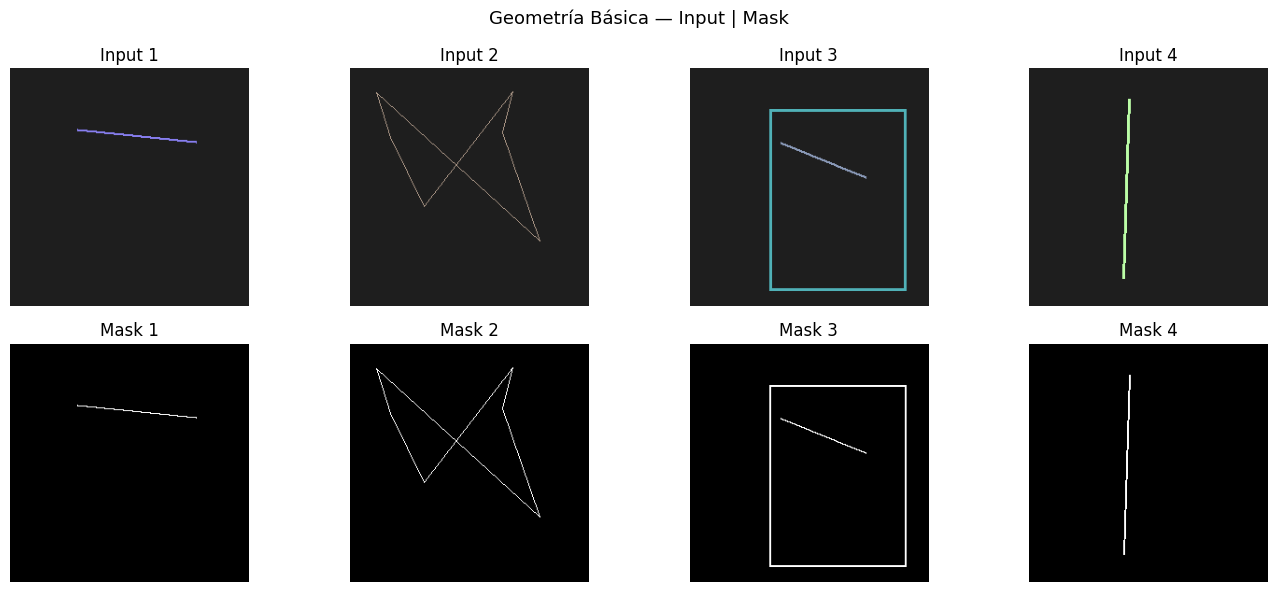

In [11]:
import matplotlib.pyplot as plt

dir_input = os.path.join(FASE_DIR, 'train', 'inputs')
dir_mask  = os.path.join(FASE_DIR, 'train', 'masks')

muestras = sorted(os.listdir(dir_input))[:4]

fig, axes = plt.subplots(2, 4, figsize=(14, 6))
fig.suptitle('Geometría Básica — Input | Mask', fontsize=13)

for col, nombre in enumerate(muestras):
    img  = Image.open(os.path.join(dir_input, nombre))
    mask = Image.open(os.path.join(dir_mask,  nombre))

    axes[0][col].imshow(img)
    axes[0][col].set_title(f'Input {col+1}')
    axes[0][col].axis('off')

    axes[1][col].imshow(mask, cmap='gray')
    axes[1][col].set_title(f'Mask {col+1}')
    axes[1][col].axis('off')

plt.tight_layout()
plt.show()

In [12]:
import numpy as np
from PIL import Image, ImageDraw, ImageFilter
import random
import json
from tqdm import tqdm

# ── Configuración ──────────────────────────────────────
IMG_SIZE   = 256
TRAIN_N    = 1000
VAL_N      = 200
TEST_N     = 200
LINE_WIDTH = 2
BG_COLOR   = 0
LINE_COLOR = 255

SUBFASE  = 'ruido'
FASE_DIR = os.path.join(BASE, 'dataset', 'fase1_entrenamiento', SUBFASE)

random.seed(99)
np.random.seed(99)

# ── Funciones de ruido ─────────────────────────────────
def agregar_ruido_gaussiano(img):
    arr   = np.array(img).astype(np.float32)
    ruido = np.random.normal(0, random.uniform(5, 25), arr.shape)
    arr   = np.clip(arr + ruido, 0, 255).astype(np.uint8)
    return Image.fromarray(arr)

def agregar_blur(img):
    radio = random.uniform(0.5, 1.5)
    return img.filter(ImageFilter.GaussianBlur(radius=radio))

def agregar_sombra(img):
    draw    = ImageDraw.Draw(img)
    x0      = random.randint(0, IMG_SIZE)
    y0      = random.randint(0, IMG_SIZE)
    x1      = random.randint(0, IMG_SIZE)
    y1      = random.randint(0, IMG_SIZE)
    opacidad = random.randint(30, 80)
    draw.rectangle([(x0,y0),(x1,y1)], fill=(0, 0, 0, opacidad))
    return img

def agregar_objeto_distractor(img, draw_img):
    # Objetos que NO son estructura — no se dibujan en la mask
    for _ in range(random.randint(1, 3)):
        tipo = random.choice(['punto', 'mancha', 'linea_corta'])

        if tipo == 'punto':
            x = random.randint(0, IMG_SIZE)
            y = random.randint(0, IMG_SIZE)
            r = random.randint(2, 8)
            color = tuple(random.randint(50, 200) for _ in range(3))
            draw_img.ellipse([(x-r, y-r),(x+r, y+r)], fill=color)

        elif tipo == 'mancha':
            x0 = random.randint(0, IMG_SIZE - 20)
            y0 = random.randint(0, IMG_SIZE - 20)
            x1 = x0 + random.randint(5, 20)
            y1 = y0 + random.randint(5, 20)
            color = tuple(random.randint(50, 180) for _ in range(3))
            draw_img.ellipse([(x0,y0),(x1,y1)], fill=color)

        elif tipo == 'linea_corta':
            x0 = random.randint(0, IMG_SIZE)
            y0 = random.randint(0, IMG_SIZE)
            x1 = x0 + random.randint(-20, 20)
            y1 = y0 + random.randint(-20, 20)
            color = tuple(random.randint(50, 180) for _ in range(3))
            draw_img.line([(x0,y0),(x1,y1)], fill=color, width=1)

    return img

def agregar_iluminacion(img):
    arr    = np.array(img).astype(np.float32)
    factor = random.uniform(0.6, 1.4)
    arr    = np.clip(arr * factor, 0, 255).astype(np.uint8)
    return Image.fromarray(arr)


# ── Generador principal ────────────────────────────────
def generar_imagen_y_mask():
    """
    Mismas figuras que geometría básica PERO con ruido.
    La mask sigue siendo perfecta — solo la imagen tiene ruido.
    """
    img  = Image.new('RGB', (IMG_SIZE, IMG_SIZE), color=(30, 30, 30))
    mask = Image.new('L',   (IMG_SIZE, IMG_SIZE), color=BG_COLOR)

    draw_img  = ImageDraw.Draw(img)
    draw_mask = ImageDraw.Draw(mask)

    num_figuras = random.randint(1, 4)

    for _ in range(num_figuras):
        figura = random.choice(['linea', 'rectangulo', 'poligono'])

        if figura == 'linea':
            x0 = random.randint(10, IMG_SIZE - 10)
            y0 = random.randint(10, IMG_SIZE - 10)
            x1 = random.randint(10, IMG_SIZE - 10)
            y1 = random.randint(10, IMG_SIZE - 10)
            color_img = tuple(random.randint(100, 255) for _ in range(3))
            draw_img.line ([(x0,y0),(x1,y1)], fill=color_img,  width=3)
            draw_mask.line([(x0,y0),(x1,y1)], fill=LINE_COLOR, width=LINE_WIDTH)

        elif figura == 'rectangulo':
            x0 = random.randint(10, IMG_SIZE // 2)
            y0 = random.randint(10, IMG_SIZE // 2)
            x1 = random.randint(IMG_SIZE // 2, IMG_SIZE - 10)
            y1 = random.randint(IMG_SIZE // 2, IMG_SIZE - 10)
            color_img = tuple(random.randint(80, 200) for _ in range(3))
            draw_img.rectangle ([(x0,y0),(x1,y1)], outline=color_img,  width=3)
            draw_mask.rectangle([(x0,y0),(x1,y1)], outline=LINE_COLOR, width=LINE_WIDTH)

        elif figura == 'poligono':
            n_puntos = random.randint(3, 6)
            puntos = [
                (random.randint(20, IMG_SIZE-20), random.randint(20, IMG_SIZE-20))
                for _ in range(n_puntos)
            ]
            color_img = tuple(random.randint(80, 200) for _ in range(3))
            draw_img.polygon (puntos, outline=color_img)
            draw_mask.polygon(puntos, outline=LINE_COLOR)

    # ── Aplicar ruido SOLO a la imagen, mask intacta ───
    agregar_objeto_distractor(img, draw_img)
    img = agregar_ruido_gaussiano(img)
    img = agregar_blur(img)
    img = agregar_iluminacion(img)

    return img, mask


# ── Guardar splits ─────────────────────────────────────
def guardar_split(split, cantidad):
    dir_input = os.path.join(FASE_DIR, split, 'inputs')
    dir_mask  = os.path.join(FASE_DIR, split, 'masks')

    for i in tqdm(range(cantidad), desc=f'  {split}'):
        img, mask = generar_imagen_y_mask()
        nombre = f'ruido_{split}_{i:04d}'
        img .save(os.path.join(dir_input, f'{nombre}.png'))
        mask.save(os.path.join(dir_mask,  f'{nombre}.png'))

# ── Ejecutar ───────────────────────────────────────────
print('🚀 Generando dataset con ruido...')
guardar_split('train', TRAIN_N)
guardar_split('val',   VAL_N)
guardar_split('test',  TEST_N)
print('✅ Dataset ruido listo')

🚀 Generando dataset con ruido...


  test: 100%|██████████| 200/200 [00:18<00:00, 10.85it/s]

✅ Dataset ruido listo


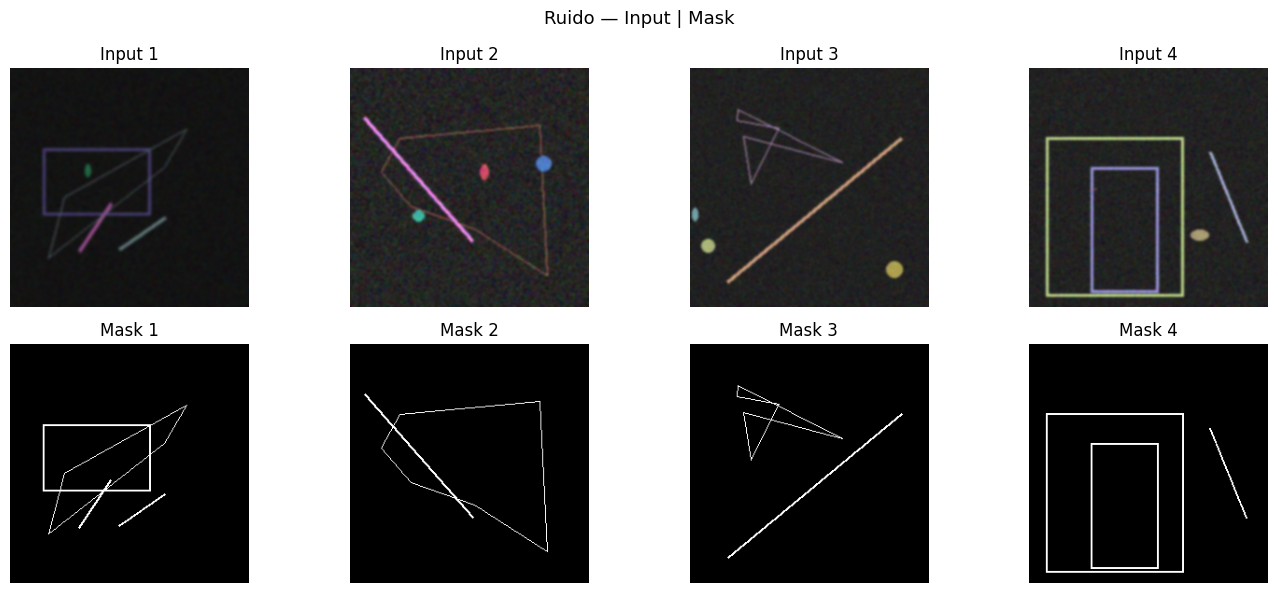

In [13]:
dir_input = os.path.join(FASE_DIR, 'train', 'inputs')
dir_mask  = os.path.join(FASE_DIR, 'train', 'masks')

muestras = sorted(os.listdir(dir_input))[:4]

fig, axes = plt.subplots(2, 4, figsize=(14, 6))
fig.suptitle('Ruido — Input | Mask', fontsize=13)

for col, nombre in enumerate(muestras):
    img  = Image.open(os.path.join(dir_input, nombre))
    mask = Image.open(os.path.join(dir_mask,  nombre))

    axes[0][col].imshow(img)
    axes[0][col].set_title(f'Input {col+1}')
    axes[0][col].axis('off')

    axes[1][col].imshow(mask, cmap='gray')
    axes[1][col].set_title(f'Mask {col+1}')
    axes[1][col].axis('off')

plt.tight_layout()
plt.show()